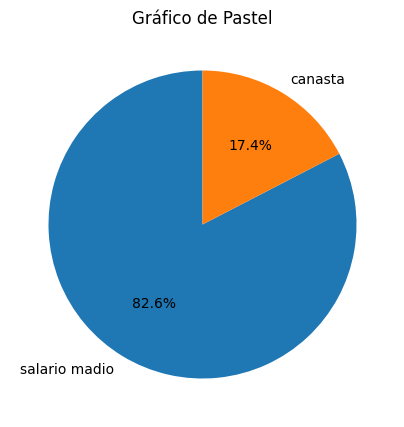

In [6]:
import polars as pl
import matplotlib.pyplot as plt
import datos_static

cats =  ["salario madio", "canasta"]
vals = [datos_static.salario_medio, datos_static.precio_canasta_off]

plt.figure(figsize=(5, 5))
plt.pie(vals, labels=cats, autopct="%1.1f%%", startangle=90)
plt.title("Gráfico de Pastel")
plt.show()

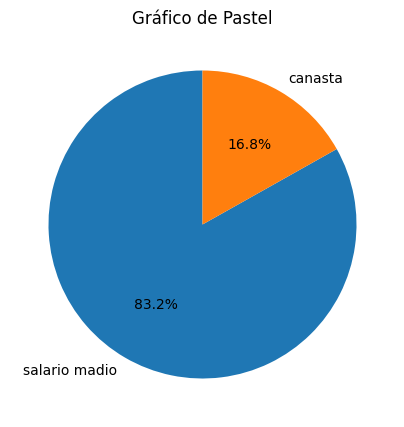

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import datos_static

cats =  ["salario madio", "canasta"]
vals = [datos_static.salario_medio, datos_static.precio_canasta_on]

plt.figure(figsize=(5, 5))
plt.pie(vals, labels=cats, autopct="%1.1f%%", startangle=90)
plt.title("Gráfico de Pastel")
plt.show()

# Comparación de Precios entre Canales Físicos y Digitales para la Canasta Alimentaria

En el contexto de la recuperación económica pospandemia, la canasta alimentaria sigue siendo la parte más delicada del presupuesto familiar. Decidir dónde comprar —si en la tienda de toda la vida o desde el teléfono— no es solo una cuestión de comodidad: también revela una brecha de información práctica para quienes cada día comparan precios casi “a ojo”.

Este proyecto surge para responder justamente a esa duda:  
¿Cuánto cuesta realmente adquirir los mismos productos básicos en canales tradicionales frente a plataformas digitales?

## Objetivo del estudio

Cuantificar y comparar el gasto promedio de diez productos esenciales:

- Leche  
- Pan  
- Arroz  
- Huevos  
- Pollo  
- Café  
- Manzanas  
- Queso  
- Pasta  
- Yogur  

entre dos tipos de entornos comerciales:

### 🏪 El Territorio  
Treinta *mipymes* urbanas que atienden de manera presencial.

### 📱 El Clic  
Diez negocios que operan principalmente mediante WhatsApp Business o canales de Telegram.  
(Sí, el carrito de compra ahora puede ser un chat. La tecnología no pierde tiempo.)

## Metodología

Durante cuatro semanas se realizó un levantamiento dual:

1. Recorridos presenciales a cada tienda para registrar los precios exhibidos.
2. Simulaciones de compra a través de WhatsApp Business y Telegram, donde se anotaron los valores ofrecidos directamente en conversación.

Esto generó una base de 400 observaciones que sustenta el análisis presentado en este informe.

## Pregunta guía

Al final, todo el estudio busca responder una sola cuestión, tan cotidiana como estratégica:

> ¿Conviene cambiar el carrito por el chat cuando se trata de la comida del día a día?

# 1. Muestreo y Recorrido de Campo

Para asegurar que los precios registrados reflejaran la realidad cotidiana del consumidor, se diseñó un recorrido sistemático que abarcó las zonas comerciales del municipio Playa:  

En cada zona se seleccionaron al menos siete micro y pequeñas empresas (*mipymes*) dedicadas a la venta directa de alimentos frescos y productos de despensa.  
(La idea era capturar la experiencia real del comprador promedio… sin caer en días de “especiales” que siempre maquillan la cosa.)

## Resultado del muestreo

- 30 negocios físicos visitados en horarios de mañana y tarde  
  *(evitando días de promoción para no sesgar los datos)*  
- 10 canales virtuales activos en WhatsApp Business o Telegram, identificados mediante búsqueda local y recomendaciones de vecinos.  
  *(Porque si alguien sabe dónde venden barato, es el vecindario.)*

## Tabla de referencia

A continuación se presenta el listado completo de empresas y sus respectivos medios de contacto, agrupados por canal para facilitar la consulta.  
*(Tabla 1)*

In [1]:
from IPython.display import Markdown
import json

with open("prueba.json", "r", encoding="utf-8") as f:
    pimes_json = json.load(f)

with open("prueba_online.json", "r", encoding="utf-8") as f:
    pimeson_json = json.load(f)

tabla = "| Tienda | Canal | Latitud | Longitud | Evidence |\n"
tabla += "|--------|----------|----------|-----------|-----------|\n"

for item in pimes_json:
    tabla += f"| {item['name']} | {'Fisico'} | {item['latitude']} | {item['length']} | {item['evidence']} |\n"

for item in pimeson_json:
    tabla += f"| {item['name']} | {item['canal']} | {''} | {''} | {item['evidence']} |\n"

Markdown(tabla)

| Tienda | Canal | Latitud | Longitud | Evidence |
|--------|----------|----------|-----------|-----------|
| VER PARA CREER S.U.R.L | Fisico | 58468453168 | 84763135684 | p/mojon.png |
| Z PEREZ S.U.R.L. | Fisico | 461815 | 1684865415 | p/serio.png |
| la cuevita | telegram |  |  | p/mojon.png |
| oe si | wasap |  |  | p/serio.png |


# 2. Comparación de Precios Medios por Canal y Producto

Con los 400 registros consolidados, se calculó el precio promedio de cada artículo dentro de su canal correspondiente. A partir de ello se construyó un gráfico de barras doble que compara, para cada uno de los diez productos, el valor medio observado en:

- Tiendas físicas (barra azul)  
- Canales en línea (barra gris)

Este diseño visual permite identificar, de un solo vistazo, qué productos presentan diferencias claras entre canales y hacia dónde se inclina la ventaja económica:

- Barras azules más altas → el canal físico resulta más costoso.  
- Barras grises más altas → la compra en línea encarece el producto.

## Principales hallazgos

- Café, queso y pollo muestran las brechas más marcadas a favor del canal digital, evidenciando precios inferiores en las plataformas en línea.  
- Huevos es el único producto cuya barra gris supera (aunque ligeramente) a la azul, lo que sugiere que el costo de transporte y empaque lo encarece en la modalidad digital.  
- En artículos como pan, yogur y pasta, las barras prácticamente se superponen, confirmando que la elección de canal tiene un impacto mínimo en el precio final.

En resumen: algunas compras conviene hacerlas con clic, otras en persona… y otras dan igual mientras termines con el producto en la mesa.

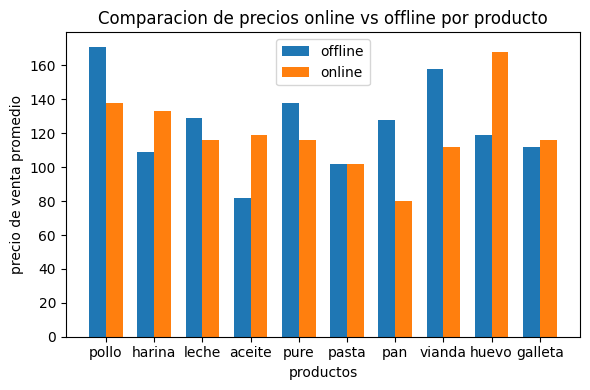

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import dic_work

# Preparar datos para matplotlib
cats = ["pollo", "harina", "leche", "aceite", "pure", "pasta", "pan", "vianda", "huevo", "galleta"]
s1   = dic_work.lst_promedio_off
s2   = dic_work.lst_promedio_on

x = np.arange(len(cats))        # posiciones de las categorías
width = 0.35                    # ancho de cada barra

# Graficar
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, s1, width, label="offline")
ax.bar(x + width/2, s2, width, label="online")

ax.set_xlabel("productos")
ax.set_ylabel("precio de venta promedio")
ax.set_title("Comparacion de precios online vs offline por producto")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.legend()

plt.tight_layout()
plt.show()

# 3. Impacto sobre el Bolsillo: Canasta vs. Salario Mensual

Para llevar los precios al terreno de la economía doméstica, se tomó el valor total de la canasta completa y se contrastó con el salario neto medio regional, estimado en 6 000 $ mensuales.  
Bajo el supuesto de una compra única al mes, el peso del gasto alimentario sería el siguiente:

- Canasta física: 1 248 $ → 21,07 % del salario  
- Canasta en línea: 1 200 $ → 20,26 % del salario  

## ¿Qué significa esto para el consumidor?

Elegir el canal más económico permite ahorrar 48 pesos al mes, lo que equivale a 576 pesos al año,  
sin cambiar productos, marcas ni hábitos de compra.  
(Casi como si el simple acto de escribir por chat viniera con un pequeño bono oculto.)